In [3]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Make plots look nice
plt.style.use('seaborn-v0_8')

# Load the dataset
df = pd.read_csv('framingham.csv')

# Check target distribution
df.drop('education', axis=1, inplace=True)
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
# Separate features (X) and target (y)
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Fill any missing numeric values with column means
X.fillna(X.mean(), inplace=True)
print("Number of features used:", X.shape[1])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


Number of features used: 14


In [5]:


# Standardize the numeric features
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)


(2966, 14) (1272, 14)


              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1079
           1       0.60      0.08      0.14       193

    accuracy                           0.85      1272
   macro avg       0.73      0.53      0.53      1272
weighted avg       0.82      0.85      0.80      1272

Model Coefficients:
 male               0.272894
age                0.568020
currentSmoker      0.014683
cigsPerDay         0.262775
BPMeds             0.027462
prevalentStroke    0.075788
prevalentHyp       0.087454
diabetes           0.009916
totChol            0.067931
sysBP              0.314991
diaBP              0.004630
BMI                0.073005
heartRate         -0.033876
glucose            0.175869
dtype: float64


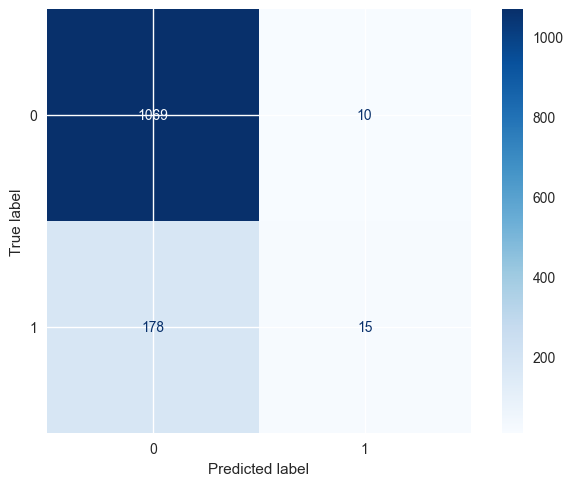

In [6]:
# Create model and fit to training data
model = LogisticRegression(
    max_iter=1000,
)
model.fit(X_train_scaled, y_train)

# Predictions & probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
confusion = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusion)
display.plot(cmap=plt.cm.Blues)

print(classification_report(y_test, y_pred))

coefficients = pd.Series(model.coef_[0], index=X.columns)
print("Model Coefficients:\n", coefficients)


AUC Score: 0.704


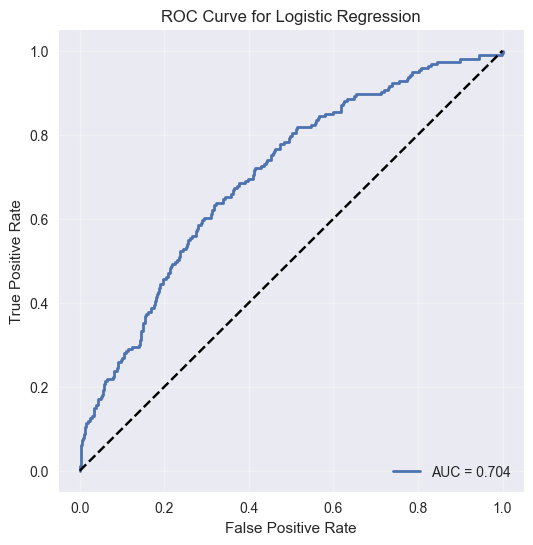

In [7]:
# ROC Curve + AUC Score
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("AUC Score:", round(roc_auc, 3))

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.3f' % roc_auc, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
